In [1]:
import os 
from yaml import safe_load
from munch import munchify
from pre.load import fits2numpy
from pre.preprocess import preprocess
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt


with open(os.getenv("CONFIG_PATH")) as f:
    cfg = munchify(safe_load(f))

In [2]:
def get_intensities(root_dir: str, cls: int) -> list:
    intensities = []
    path = os.path.join(root_dir, str(cls))
    for file in tqdm(os.listdir(path)):
        data_raw = fits2numpy(os.path.join(path, file))
        data = preprocess(data_raw)
        intensities.append(data.sum())
    return intensities

In [3]:
def get_intensities_morph(root_dir: str, files: list[str]) -> list:
    intensities = []
    for file in tqdm(files):
        folder = file.split('_')[0] 
        data_raw = fits2numpy(os.path.join(root_dir, folder, file))
        data = preprocess(data_raw)
        intensities.append(data.sum())
    return intensities

In [4]:
import pandas as pd

classification = pd.read_csv("/home/zagorulia/ml/classification.csv", index_col=0)
classification.head()

,file,prob,pred
0,J0000+0248_C_2016_01_03_pet_map.fits,0.000089,0
1,J0000+0248_S_2022_01_07_pet_map.fits,0.000024,0
2,J0000+0248_X_2016_01_03_pet_map.fits,0.081690,0
3,J0000+0248_X_2022_01_07_pet_map.fits,0.001513,0
4,J0000+0307_C_2015_12_23_pet_map.fits,0.027874,0


In [8]:
classification['pred'].value_counts()

pred
0    72108
1    61938
Name: count, dtype: int64

In [6]:
point_sources = classification[classification.prob < 0.25]
jet_sources = classification[classification.prob > 0.75]
point_sources_ints2 = get_intensities_morph(cfg.fits_path, point_sources.file.tolist())
jet_sources_ints2 = get_intensities_morph(cfg.fits_path, jet_sources.file.tolist())

  0%|          | 0/64532 [00:00<?, ?it/s]

  1%|          | 457/64532 [00:05<11:43, 91.10it/s] 


KeyboardInterrupt: 

In [ ]:
point_sources_ints = get_intensities(cfg.val_path, 0)
jet_sources_ints = get_intensities(cfg.val_path, 2)

100%|██████████| 248/248 [00:04<00:00, 57.08it/s]


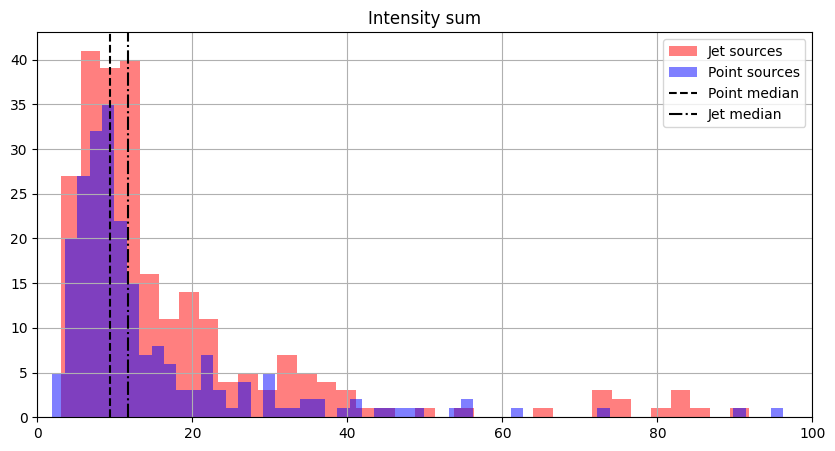

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.hist(np.array(jet_sources_ints).ravel(), bins=100, alpha=0.5, color='red', label='Jet sources')
ax.hist(np.array(point_sources_ints).ravel(), bins=100, alpha=0.5, color='blue', label='Point sources')

# ax.axvline(np.array(point_sources_ints).mean(), ls='--', color='black', label='Point mean')
ax.axvline(np.median(np.array(point_sources_ints)), ls='--', color='black', label='Point median')
# ax.axvline(np.array(jet_sources_ints).mean(), ls='-.', color='black', label='Jet mean')
ax.axvline(np.median(np.array(jet_sources_ints)), ls='-.', color='black', label='Jet median')
ax.set_title('Intensity sum')
ax.set_xlim(0, 100)
ax.grid(True)
ax.legend()

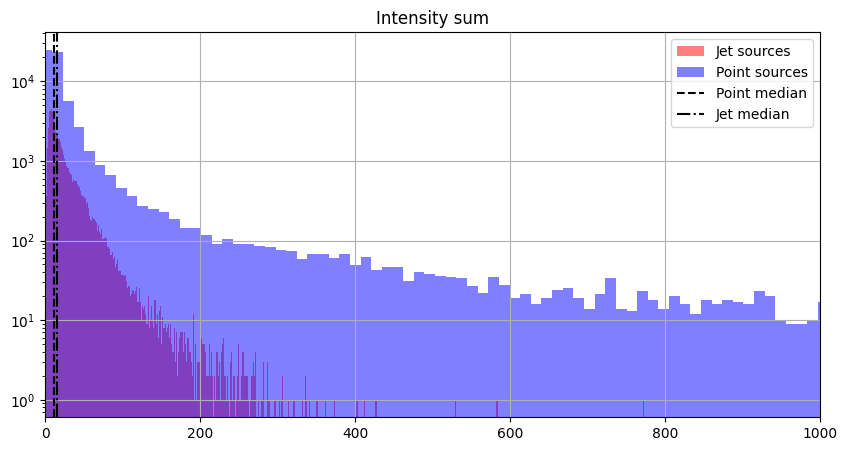

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.hist(np.array(jet_sources_ints2).ravel(), bins=1000, alpha=0.5, color='red', label='Jet sources')
ax.hist(np.array(point_sources_ints2).ravel(), bins=1000, alpha=0.5, color='blue', label='Point sources')
# same bins

ax.axvline(np.median(np.array(point_sources_ints2)), ls='--', color='black', label='Point median')
ax.axvline(np.median(np.array(jet_sources_ints2)), ls='-.', color='black', label='Jet median')
ax.set_title('Intensity sum')
# ax.set_xlim(0, 1000)
ax.set_yscale('log')
ax.grid(True)
ax.legend()

In [ ]:
import numpy as np
from scipy.stats import mannwhitneyu

def dominance_stats(A, B):
    # one-sided MWU: H1: A > B
    U, p = mannwhitneyu(A, B, alternative="greater")

    n1, n2 = len(A), len(B)

    # Cliff's delta
    delta = (2*U)/(n1*n2) - 1

    # dominance probability
    P = (U)/(n1*n2)

    return {
        "p_value": p,
        "P(A > B)": P,
        "Cliffs_delta": delta
    }

In [ ]:
dominance_stats(jet_sources_ints, point_sources_ints)

{'p_value': np.float32(0.0026603492),
 'P(A > B)': np.float32(0.57424575),
 'Cliffs_delta': np.float32(0.1484915)}

In [ ]:
dominance_stats(jet_sources_ints2, point_sources_ints2)

{'p_value': np.float32(0.0),
 'P(A > B)': np.float32(0.56025565),
 'Cliffs_delta': np.float32(0.12051129)}